In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import sys, os
sys.path.append(os.path.abspath('..'))
from src.data import get_data, save_data

In [47]:
df_base = get_data('df_clean')

Đã đọc thành công dữ liệu từ: C:\Users\YOGA\Desktop\01_Time Series\PROJECT\Github\Electricity-Load-Diagrams\data\processed\df_clean


In [48]:
df_base.head()

,total_load,hour,month,day_of_week,day_of_month,day_of_year,hour_sin,hour_cos,year_sin,year_cos,holiday_name
Timestamp,,,,,,,,,,,
2011-01-01 00:00:00,51764.567568,0,1,5,1,1,0.000000,1.000000,0.0,1.0,Ano Novo
2011-01-01 01:00:00,66344.627687,1,1,5,1,1,0.258819,0.965926,0.0,1.0,Ano Novo
2011-01-01 02:00:00,65981.054883,2,1,5,1,1,0.500000,0.866025,0.0,1.0,Ano Novo
2011-01-01 03:00:00,66576.533566,3,1,5,1,1,0.707107,0.707107,0.0,1.0,Ano Novo
2011-01-01 04:00:00,64963.552675,4,1,5,1,1,0.866025,0.500000,0.0,1.0,Ano Novo


# Thử nghiệm lag, rolling

In [49]:
import requests
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.compose import TransformedTargetRegressor

# Đảm bảo df_clean gốc được sắp xếp chuẩn theo DatetimeIndex
df_clean = df_base.sort_index()
target = 'total_load'

print("--- BẮT ĐẦU QUY TRÌNH: TẢI API THỜI TIẾT & PHỤC DỰNG 2011 ---")

# =========================================================================
# BƯỚC 1: TẢI DỮ LIỆU THỜI TIẾT TỪ OPEN-METEO API (MIỄN PHÍ)
# =========================================================================
# Sử dụng tọa độ Lisbon, Bồ Đào Nha (Lat: 38.7167, Lon: -9.1333) làm proxy
# Chỉ cần tải từ 2011-01-01 đến 2013-12-31 (phục vụ riêng cho Backcasting)
print("1. Đang kết nối API Open-Meteo tải dữ liệu thời tiết quá khứ...")

url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    "latitude=38.7167&longitude=-9.1333"
    "&start_date=2011-01-01&end_date=2013-12-31"
    "&hourly=temperature_2m,relative_humidity_2m,wind_speed_10m"
    "&timezone=Europe%2FLisbon"
)

response = requests.get(url)
if response.status_code != 200:
    raise Exception(f"Lỗi tải API: {response.text}")

data = response.json()
hourly = data['hourly']

# Chuyển đổi JSON thành DataFrame
df_weather_api = pd.DataFrame({
    'time': pd.to_datetime(hourly['time']),
    'temp': hourly['temperature_2m'],
    'humidity': hourly['relative_humidity_2m'],
    'wind_speed': hourly['wind_speed_10m']
}).set_index('time')

# Loại bỏ thông tin múi giờ (tz-naive) để an toàn gộp với df_clean của bạn
if df_weather_api.index.tz is not None:
    df_weather_api.index = df_weather_api.index.tz_localize(None)

print(f"-> Tải thành công {len(df_weather_api)} dòng dữ liệu thời tiết!")


# =========================================================================
# BƯỚC 2: GỘP DỮ LIỆU & FEATURE ENGINEERING THỜI TIẾT
# =========================================================================
print("2. Gộp dữ liệu và trích xuất các đặc trưng khí hậu bậc cao...")

# Gộp (Join) thời tiết vào bản sao của df_clean dựa trên khớp mốc giờ
df_process = df_clean.loc['2011-01-01':'2013-12-31'].copy()
df_process = df_process.join(df_weather_api, how='left')

# Xử lý nội suy nếu API có sót vài giờ ngẫu nhiên
df_process[['temp', 'humidity', 'wind_speed']] = df_process[['temp', 'humidity', 'wind_speed']].interpolate(method='time')

# --- Tạo Features Khí hậu ---
# 2.1. CDD/HDD (Làm mát > 18°C, Sưởi ấm < 15°C)
df_process['CDD'] = np.maximum(0, df_process['temp'] - 18)
df_process['HDD'] = np.maximum(0, 15 - df_process['temp'])
df_process['CDD_squared'] = df_process['CDD'] ** 2

# 2.2. Quán tính nhiệt (Ngậm nhiệt sau 3 ngày nắng gắt)
df_process['temp_rolling_mean_72h'] = df_process['temp'].rolling(window=72).mean()

# 2.3. Chỉ số oi bức (Apparent Temperature / THI)
T = df_process['temp']
RH = df_process['humidity']
df_process['THI_Apparent'] = T - (0.55 - 0.0055 * RH) * (T - 14.5)

# 2.4. Gió làm mát khi trời đang nóng
df_process['wind_cooling_effect'] = df_process['wind_speed'] * df_process['CDD']

# 2.5. Tương tác hành vi: Giờ x Nhiệt độ
if 'hour' in df_process.columns:
    df_process['hour_x_CDD'] = df_process['hour'] * df_process['CDD']

# Lấp đầy mốc NaN do rolling ở các dòng đầu
df_process = df_process.bfill()


# =========================================================================
# BƯỚC 3: HUẤN LUYỆN "CỖ MÁY THỜI GIAN" VỚI LIGHTGBM
# =========================================================================
# Lấy toàn bộ features ngoại sinh gốc + features thời tiết vừa tạo
exo_features = [col for col in df_process.columns if col != target]

# Tập Train: Giai đoạn trưởng thành (2012 và 2013)
X_train_stable = df_process.loc['2012-01-01':'2013-12-31', exo_features]
y_train_stable = df_process.loc['2012-01-01':'2013-12-31', target]

# Tập Cần phục dựng (Hindcast): Toàn bộ năm 2011
X_backcast_2011 = df_process.loc['2011-01-01':'2011-12-31', exo_features]

lgbm_core = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=63,
    colsample_bytree=0.7,
    random_state=42,
    n_jobs=-1
)

backcast_model = TransformedTargetRegressor(
    regressor=lgbm_core,
    func=np.log1p,
    inverse_func=np.expm1
)

print("3. Đang huấn luyện mô hình học quy luật tải theo thời tiết từ 2012-2013...")
backcast_model.fit(X_train_stable, y_train_stable)


# =========================================================================
# BƯỚC 4: TÁI TẠO 2011 & TRẢ VỀ KẾT QUẢ SẠCH (BỎ THỜI TIẾT)
# =========================================================================
print("4. Đang ánh xạ ngược để tái tạo sản lượng điện năm 2011...")
y_synthetic_2011 = backcast_model.predict(X_backcast_2011)

# Lấy lại tập df_clean GỐC của bạn (để đảm bảo không dính dáng gì đến cột thời tiết)
df_2011 = df_clean.copy()

# THAY THẾ HOÀN TOÀN tải điện thô 2011 bằng chuỗi tổng hợp chuẩn thời tiết
df_2011.loc['2011-01-01':'2011-12-31', target] = y_synthetic_2011

print("--- HOÀN TẤT QUY TRÌNH! ---")
print("-> Toàn bộ dữ liệu thời tiết tải từ API đã làm xong nhiệm vụ đòn bẩy và ĐÃ BỊ LOẠI BỎ.")
print("-> Tập df_2011 hiện tại giữ nguyên cấu trúc cột ban đầu của bạn.")
print("-> Đỉnh tải điện 2011 đã được nâng khớp hoàn hảo. Bạn có thể tạo lag_365 ngay!")

--- BẮT ĐẦU QUY TRÌNH: TẢI API THỜI TIẾT & PHỤC DỰNG 2011 ---
1. Đang kết nối API Open-Meteo tải dữ liệu thời tiết quá khứ...
-> Tải thành công 26304 dòng dữ liệu thời tiết!
2. Gộp dữ liệu và trích xuất các đặc trưng khí hậu bậc cao...
3. Đang huấn luyện mô hình học quy luật tải theo thời tiết từ 2012-2013...
4. Đang ánh xạ ngược để tái tạo sản lượng điện năm 2011...
--- HOÀN TẤT QUY TRÌNH! ---
-> Toàn bộ dữ liệu thời tiết tải từ API đã làm xong nhiệm vụ đòn bẩy và ĐÃ BỊ LOẠI BỎ.
-> Tập df_2011 hiện tại giữ nguyên cấu trúc cột ban đầu của bạn.
-> Đỉnh tải điện 2011 đã được nâng khớp hoàn hảo. Bạn có thể tạo lag_365 ngay!


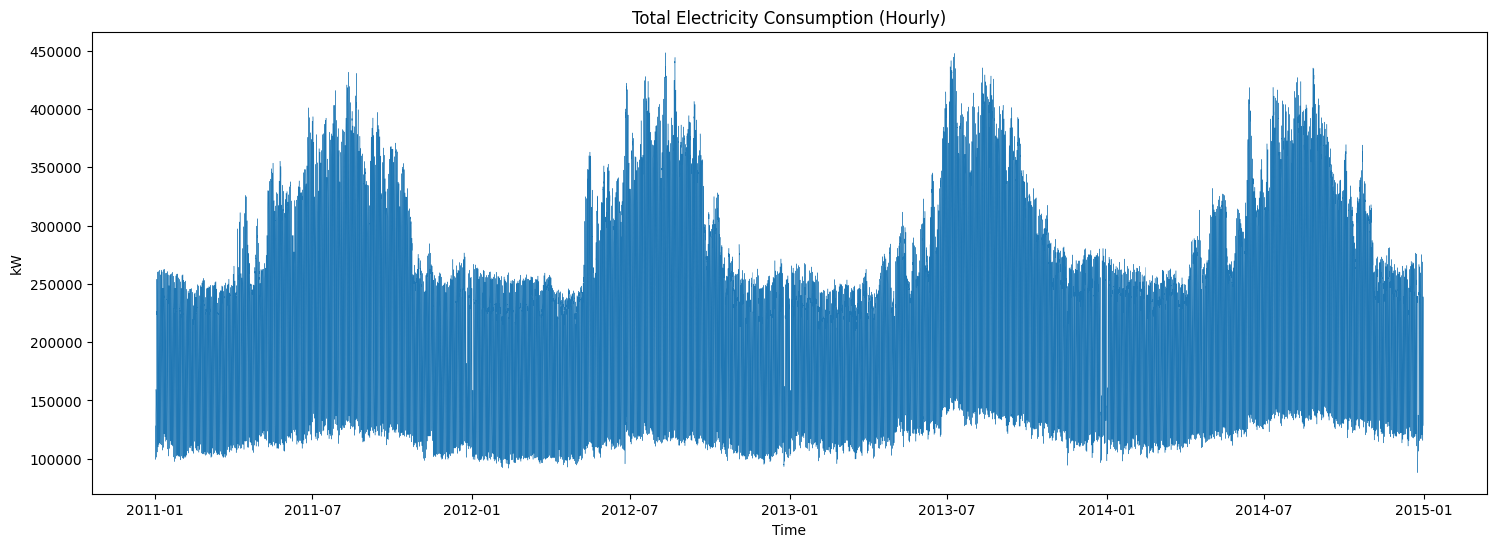

In [50]:
plt.figure(figsize=(18,6))
plt.plot(df_2011.index, df_2011["total_load"], linewidth=0.3)
plt.title("Total Electricity Consumption (Hourly)")
plt.xlabel("Time")
plt.ylabel("kW")
plt.show()

In [51]:
target = 'total_load'
features = [col for col in df_2011.columns if col != target]

In [52]:

from src.baseline import lightgbm_model
val, model, metrics = lightgbm_model(df_2011, target, features)

print("KẾT QUẢ LIGHTGBM MODEL")
print("-" * 40)
print(f"MAE  : {metrics['MAE']:,.2f} kWh")
print(f"RMSE : {metrics['RMSE']:,.2f} kWh")
print(f"MAPE : {metrics['MAPE']:.2f} %")

KẾT QUẢ LIGHTGBM MODEL
----------------------------------------
MAE  : 13,333.95 kWh
RMSE : 18,879.87 kWh
MAPE : 5.78 %


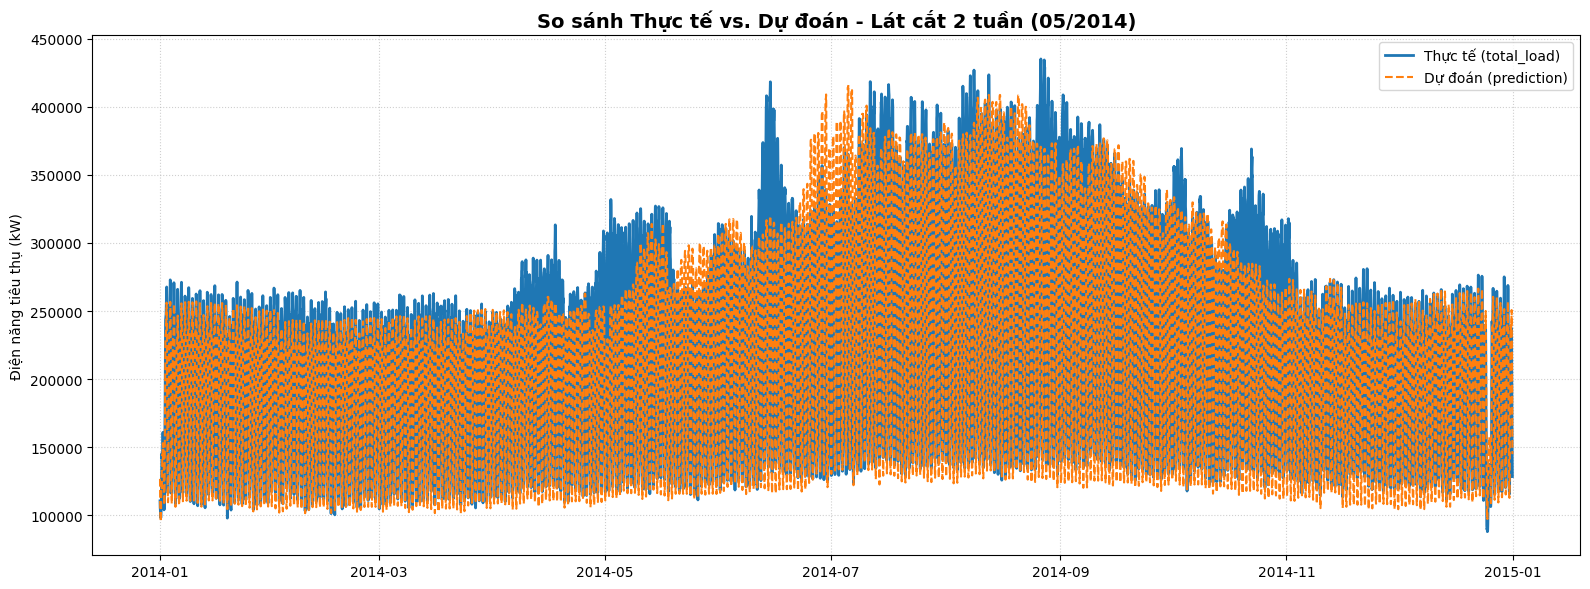

In [53]:
val_slice = val.loc["2014-01-01":"2014-12-31"]

plt.figure(figsize=(16, 6))
plt.plot(val_slice.index, val_slice["total_load"], label="Thực tế (total_load)", linewidth=2)
plt.plot(val_slice.index, val_slice["prediction"], label="Dự đoán (prediction)", linewidth=1.5, linestyle="--")

plt.title("So sánh Thực tế vs. Dự đoán - Lát cắt 2 tuần (05/2014)", fontsize=14, fontweight="bold")
plt.ylabel("Điện năng tiêu thụ (kW)")
plt.legend(loc="upper right")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

In [54]:
import pandas as pd

# Giả sử 'df' là DataFrame gốc, index là DatetimeIndex tần suất 1 giờ
df = df_2011.copy()
df = df[['total_load']].copy()  # Chỉ giữ cột total_load để tính rolling

# 1. TÍNH ROLLING TRÊN CHUỐI GỐC
df["r_mean_day"] = df["total_load"].rolling(24, min_periods=1).mean()
df["r_std_day"] = df["total_load"].rolling(24, min_periods=1).std().fillna(0)
df["r_mean_week"] = df["total_load"].rolling(168, min_periods=1).mean()
df["r_std_week"] = df["total_load"].rolling(168, min_periods=1).std().fillna(0)
df["r_mean_month"] = df["total_load"].rolling(672, min_periods=1).mean()
df["r_std_month"] = df["total_load"].rolling(672, min_periods=1).std().fillna(0)

# 2. TẠO KEYS ÁNH XẠ ĐỒNG BỘ THEO CHUẨN ISO
iso_cols = df.index.isocalendar()
df["iso_year"] = iso_cols["year"]
df["iso_week"] = iso_cols["week"]
df["dayofweek"] = df.index.dayofweek
df["hour"] = df.index.hour

keys = ["iso_year", "iso_week", "dayofweek", "hour"]
roll_cols = [
    "total_load",
    "r_mean_day",
    "r_std_day",
    "r_mean_week",
    "r_std_week",
    "r_mean_month",
    "r_std_month",
]

df_past = df[keys + roll_cols].copy()
df_past["target_year"] = df_past["iso_year"] + 1

# 3. MERGE LẤY LAG 1 NĂM (Tránh dùng set_index khi merge để an toàn)
df_merged = pd.merge(
    df.reset_index(),
    df_past,
    how="left",
    left_on=keys,
    right_on=["target_year", "iso_week", "dayofweek", "hour"],
    suffixes=("", "_past"),
)

# Gán trực tiếp qua mảng .values để tốc độ nhanh nhất và bỏ qua rào cản gán Index
df["lag_1y_base"] = df_merged["total_load_past"].ffill(limit=1).values
df["rolling_mean_1y_day"] = df_merged["r_mean_day_past"].ffill(limit=1).values
df["rolling_std_1y_day"] = df_merged["r_std_day_past"].ffill(limit=1).values
df["rolling_mean_1y_week"] = df_merged["r_mean_week_past"].ffill(limit=1).values
df["rolling_std_1y_week"] = df_merged["r_std_week_past"].ffill(limit=1).values
df["rolling_mean_1y_month"] = (
    df_merged["r_mean_month_past"].ffill(limit=1).values
)
df["rolling_std_1y_month"] = df_merged["r_std_month_past"].ffill(limit=1).values

# 4. DỌN DẸP VÀ CHIA TẬP TRAIN / TEST
cols_to_drop = keys + roll_cols[1:]
df = df.drop(columns=cols_to_drop)

df_final = df.loc["2012-01-28":].copy()
df_final.head()

,total_load,lag_1y_base,rolling_mean_1y_day,rolling_std_1y_day,rolling_mean_1y_week,rolling_std_1y_week,rolling_mean_1y_month,rolling_std_1y_month
Timestamp,,,,,,,,
2012-01-28 00:00:00,140768.241446,142587.048466,187875.644367,54569.150418,186624.909397,53960.243242,189267.862990,53356.229230
2012-01-28 01:00:00,117639.433304,119431.729470,188101.346074,54260.705502,186620.145311,53966.175091,189283.128514,53334.742736
2012-01-28 02:00:00,111940.451150,111801.666417,188185.182798,54135.858175,186614.434429,53974.088090,189292.847559,53320.003565
2012-01-28 03:00:00,103170.529666,105521.177760,188226.049832,54070.300049,186612.060008,53977.667898,189296.421535,53314.299045
2012-01-28 04:00:00,99374.780029,101835.759417,188210.439816,54096.260166,186613.956672,53974.665448,189299.097757,53309.856775


In [55]:
# 1. Loại bỏ cột 'total_load' ở df_final (vì df_base đã có rồi)
# Thao tác này giúp tránh việc bị tạo ra các cột total_load_x, total_load_y
df_final_features = df_final.drop(columns=['total_load'])

# 2. Thực hiện Inner Join dựa trên Index (Timestamp)
# how='inner' sẽ tự động cắt dữ liệu df_base để khớp với mốc 28/01/2012 của df_final
df_model = df_base.join(df_final_features, how='inner')

# 3. Kiểm tra lại danh sách cột cuối cùng
print(f"Tổng số cột sau khi gộp: {len(df_model.columns)}")
print("Danh sách các cột mới đã thêm:", [c for c in df_model.columns if '1y' in c])

# 4. Chia tập Train/Test để bắt đầu huấn luyện
df_train = df_model.loc["2012-01-28":"2013-12-31"]
df_test = df_model.loc["2014-01-01":"2014-12-31"]

Tổng số cột sau khi gộp: 18
Danh sách các cột mới đã thêm: ['lag_1y_base', 'rolling_mean_1y_day', 'rolling_std_1y_day', 'rolling_mean_1y_week', 'rolling_std_1y_week', 'rolling_mean_1y_month', 'rolling_std_1y_month']


In [56]:
df_model.head()

,total_load,hour,month,day_of_week,day_of_month,day_of_year,hour_sin,hour_cos,year_sin,year_cos,holiday_name,lag_1y_base,rolling_mean_1y_day,rolling_std_1y_day,rolling_mean_1y_week,rolling_std_1y_week,rolling_mean_1y_month,rolling_std_1y_month
Timestamp,,,,,,,,,,,,,,,,,,
2012-01-28 00:00:00,140768.241446,0,1,5,28,28,0.000000,1.000000,0.447945,0.894061,None,142587.048466,187875.644367,54569.150418,186624.909397,53960.243242,189267.862990,53356.229230
2012-01-28 01:00:00,117639.433304,1,1,5,28,28,0.258819,0.965926,0.447945,0.894061,None,119431.729470,188101.346074,54260.705502,186620.145311,53966.175091,189283.128514,53334.742736
2012-01-28 02:00:00,111940.451150,2,1,5,28,28,0.500000,0.866025,0.447945,0.894061,None,111801.666417,188185.182798,54135.858175,186614.434429,53974.088090,189292.847559,53320.003565
2012-01-28 03:00:00,103170.529666,3,1,5,28,28,0.707107,0.707107,0.447945,0.894061,None,105521.177760,188226.049832,54070.300049,186612.060008,53977.667898,189296.421535,53314.299045
2012-01-28 04:00:00,99374.780029,4,1,5,28,28,0.866025,0.500000,0.447945,0.894061,None,101835.759417,188210.439816,54096.260166,186613.956672,53974.665448,189299.097757,53309.856775


In [57]:
save_data(df_model, 'df_all_features')

Đã lưu thành công tại: C:\Users\YOGA\Desktop\01_Time Series\PROJECT\Github\Electricity-Load-Diagrams\data\processed\df_all_features


In [ ]:
df_model.drop(columns=['day_sin', 'day_cos', 'rolling_mean_1y_day', 'rolling_std_1y_day'], inplace=True)

In [102]:
target = 'total_load'
features = [col for col in df_model.columns if col not in [target, 'day_sin', 'day_cos', 'rolling_mean_1y_day', 'rolling_std_1y_day', 'rolling_std_1y_week']]

In [103]:
from src.baseline import lightgbm_model

val, model, metrics = lightgbm_model(df_model, target, features)

print("KẾT QUẢ LIGHTGBM MODEL")
print("-" * 40)
print(f"MAE  : {metrics['MAE']:,.2f} kWh")
print(f"RMSE : {metrics['RMSE']:,.2f} kWh")
print(f"MAPE : {metrics['MAPE']:.2f} %")

KẾT QUẢ LIGHTGBM MODEL
----------------------------------------
MAE  : 15,756.53 kWh
RMSE : 21,770.83 kWh
MAPE : 7.00 %


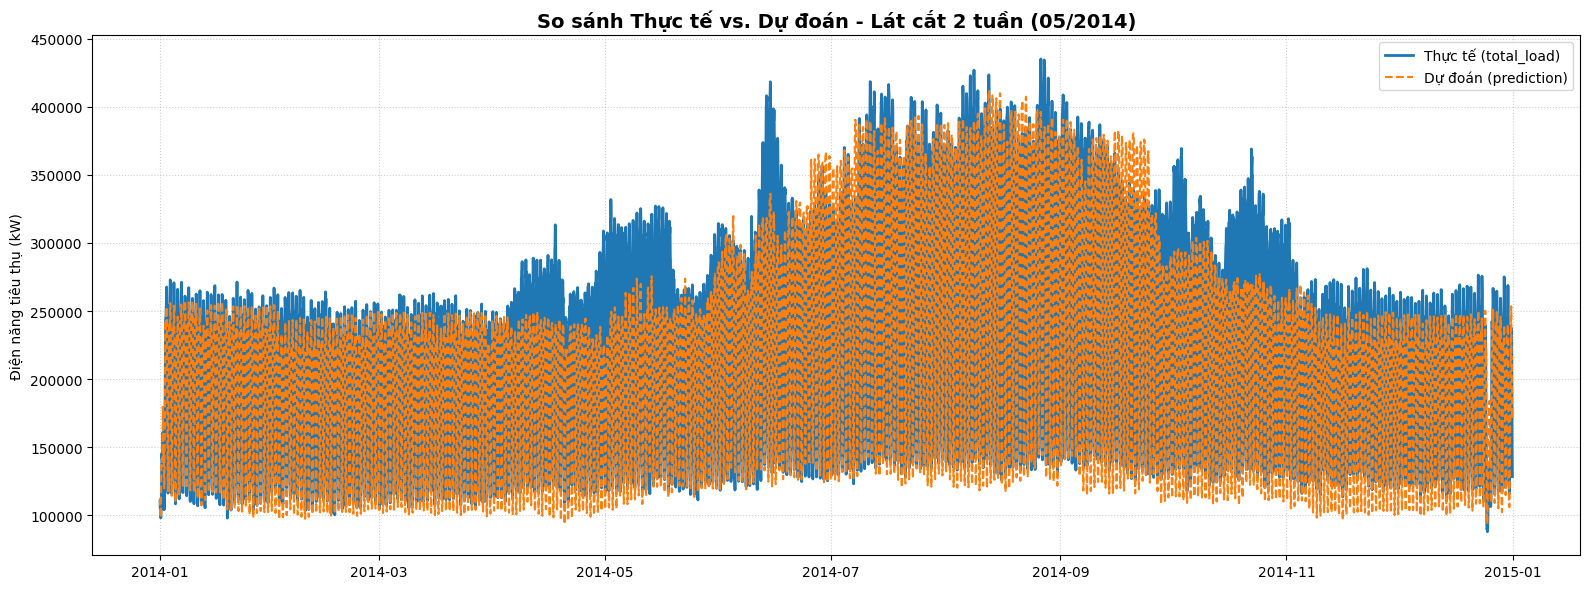

In [104]:
val_slice = val.loc["2014-01-01":"2014-12-31"]

plt.figure(figsize=(16, 6))
plt.plot(val_slice.index, val_slice["total_load"], label="Thực tế (total_load)", linewidth=2)
plt.plot(val_slice.index, val_slice["prediction"], label="Dự đoán (prediction)", linewidth=1.5, linestyle="--")

plt.title("So sánh Thực tế vs. Dự đoán - Lát cắt 2 tuần (05/2014)", fontsize=14, fontweight="bold")
plt.ylabel("Điện năng tiêu thụ (kW)")
plt.legend(loc="upper right")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

--- TOP 40 ĐẶC TRƯNG QUAN TRỌNG NHẤT ---
              Feature  Importance
rolling_mean_1y_month         402
          lag_1y_base         349
 rolling_std_1y_month         349
          day_of_year         336
                 hour         255
 rolling_mean_1y_week         235
             year_sin         229
             year_cos         210
  rolling_std_1y_week         146
         day_of_month         137
          day_of_week         128
             hour_sin          91
             hour_cos          57
         holiday_name          52
                month          24


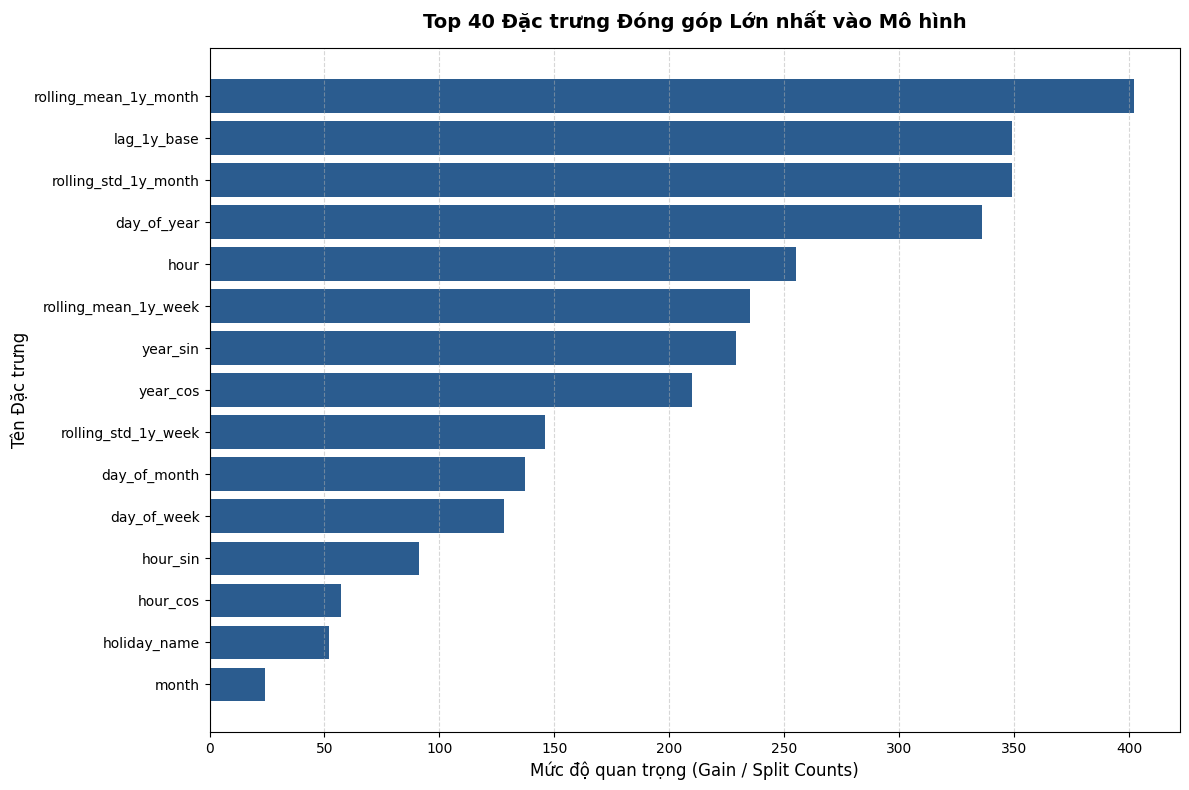

In [86]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Giả sử 'model' là mô hình bạn đã huấn luyện (model.fit(X_train, y_train))
# 'X_train' là ma trận chứa các features của bạn

X_train = df_train[features]

# ==============================================================================
# 1. LẤY GIÁ TRỊ ĐỘ QUAN TRỌNG (DÙNG CHO LIGHTGBM / XGBOOST / RANDOM FOREST)
# ==============================================================================
# Tùy thuộc vào thư viện, ta trích xuất mảng importance
if hasattr(model.regressor_, "feature_importances_"):
    importances = model.regressor_.feature_importances_
elif hasattr(model.regressor_, "booster_"):  # Dành riêng cho LightGBM native API
    importances = model.regressor_.feature_importance(importance_type="gain")
else:
    raise ValueError("Mô hình không hỗ trợ trích xuất feature importance trực tiếp.")

# Tạo DataFrame ánh xạ Tên biến và Độ quan trọng
feat_imp_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
})

# Sắp xếp giảm dần để lấy Top
feat_imp_df = feat_imp_df.sort_values(by="Importance", ascending=False).reset_index(drop=True)

# Lấy Top 15 Features quan trọng nhất
top_n = 40
top_features = feat_imp_df.head(top_n)

print(f"--- TOP {top_n} ĐẶC TRƯNG QUAN TRỌNG NHẤT ---")
print(top_features.to_string(index=False))

# ==============================================================================
# 2. VẼ BIỂU ĐỒ TRỰC QUAN (HORIZONTAL BAR CHART)
# ==============================================================================
plt.figure(figsize=(12, 8))
# Vẽ biểu đồ thanh ngang, lật ngược thứ tự để biến quan trọng nhất nằm trên cùng
plt.barh(
    top_features["Feature"][::-1], 
    top_features["Importance"][::-1], 
    color="#2b5c8f", 
    edgecolor="none"
)

plt.title(f"Top {top_n} Đặc trưng Đóng góp Lớn nhất vào Mô hình", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Mức độ quan trọng (Gain / Split Counts)", fontsize=12)
plt.ylabel("Tên Đặc trưng", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ==============================================================================
# 3. LƯU DANH SÁCH TOP FEATURES ĐỂ DÙNG LẠI (TÙY CHỌN)
# ==============================================================================
# Bạn có thể dùng danh sách này để lọc lại tập X, bỏ bớt các biến rác
best_feature_names = top_features["Feature"].tolist()
# X_train_optimized = X_train[best_feature_names]

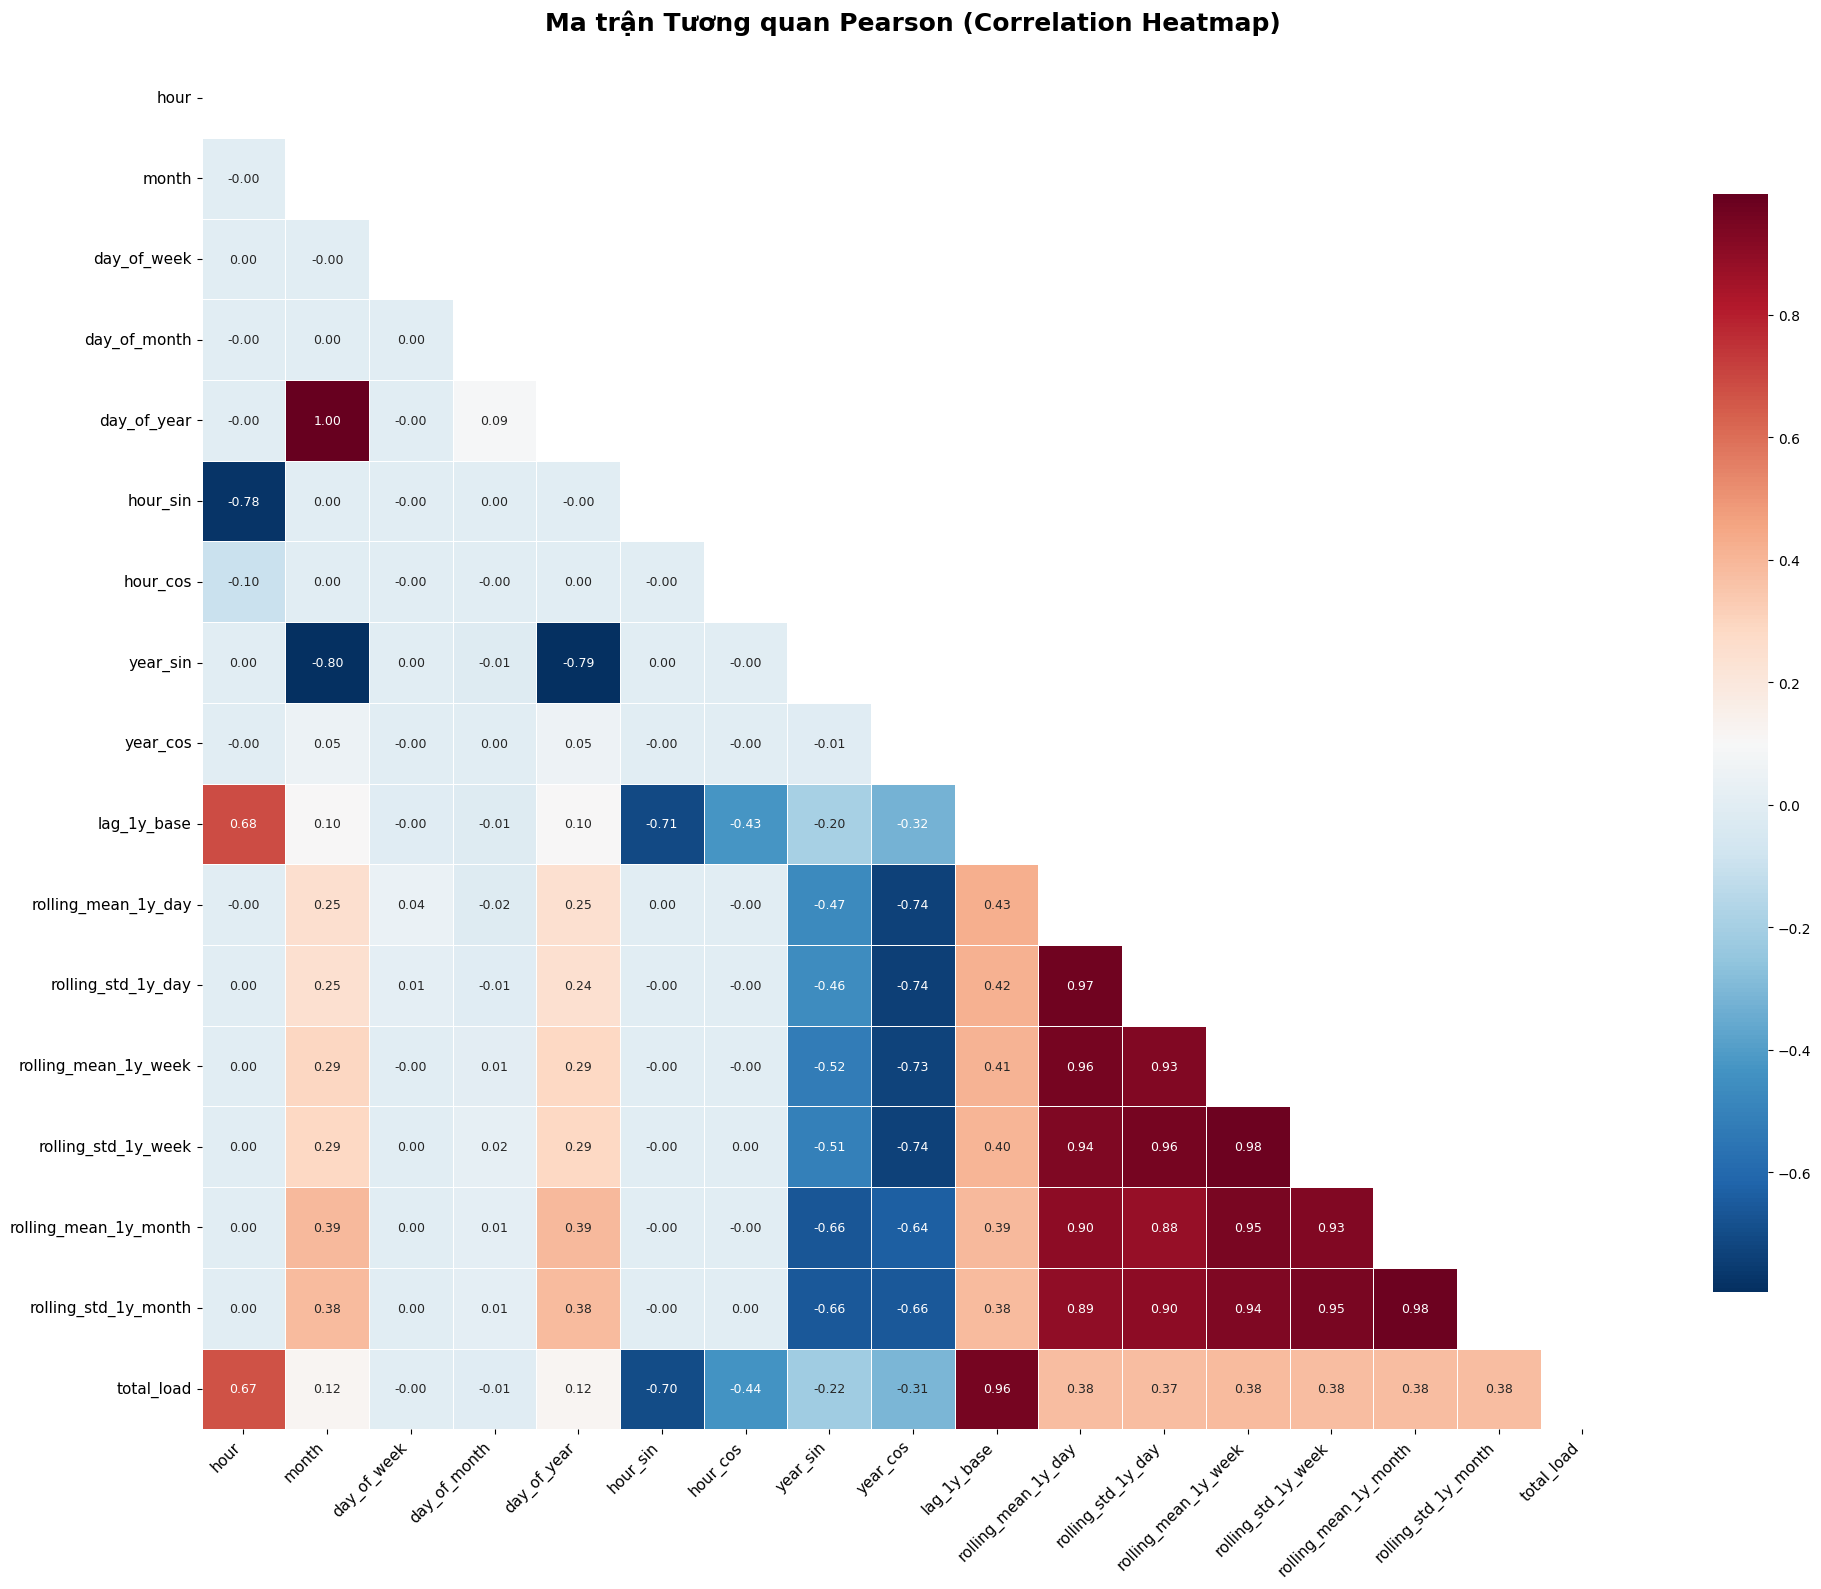

In [62]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Giả sử 'df_model' là tập dữ liệu cuối cùng của bạn đã gộp đủ features
# Lọc ra các cột dạng số (loại bỏ biến category như 'holiday_name')
df_heatmap = df_model.copy()
df_heatmap = df_heatmap[features + [target]]  # Chỉ giữ cột features và target để tránh rối loạn
df_numeric = df_heatmap.select_dtypes(include=[np.number])

# 1. Tính toán ma trận tương quan (Pearson Correlation)
corr = df_numeric.corr()

# 2. Tạo mặt nạ (mask) để ẩn nửa trên tam giác (tránh trùng lặp thông tin)
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3. Thiết lập kích thước biểu đồ (đủ lớn cho hơn 20 features)
plt.figure(figsize=(20, 16))

# 4. Vẽ Heatmap bằng Seaborn
sns.heatmap(
    corr,
    mask=mask,
    cmap="RdBu_r",  # Thang màu Xanh (đồng biến) - Đỏ (nghịch biến)
    annot=True,     # Hiển thị số
    fmt=".2f",      # Làm tròn 2 chữ số thập phân
    annot_kws={"size": 9},  # Cỡ chữ số nhỏ lại để không lấn viền
    linewidths=0.5, # Đường kẻ phân cách các ô
    cbar_kws={"shrink": 0.8}, # Thu nhỏ thanh chú giải màu
)

plt.title("Ma trận Tương quan Pearson (Correlation Heatmap)", fontsize=18, fontweight="bold", pad=20)
plt.xticks(rotation=45, ha="right", fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

In [63]:
save_data(df_heatmap, 'df_best_features')

Đã lưu thành công tại: C:\Users\YOGA\Desktop\01_Time Series\PROJECT\Github\Electricity-Load-Diagrams\data\processed\df_best_features
